In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
pip install pd

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Parameters

from utils.dynamicRieszFunctions import estimateDynamicRiesz_all
from utils.dynamicRieszFunctions import estimateDynamicRiesz
from utils.estimateDiDLinear import estimateDiDLinear
from utils.estimateDiD_OLS import estimateDiD_OLS
import torch
import pandas as pd
import time
from torch.distributions import Normal
from utils.dgp import DiD_DGP
import statsmodels.api as sm

from utils.application import *
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import pandas as pd

lasso_cv_settings = {
    'b_degree' : 1,
    'cv_folds' : 5,
    'random_state' : 42
}

lasso_a_settings = {
    'lambda_val' : 10,
    'beta_start' : None,
    'D_LB' : 0,
    'D_add' : 0.2,
    'c1' : "CV",
    'c2' : 0.1,
    'tol' : 1e-5,
    'max_iter' : 100,
    'b_degree' : 1,
    'control' : {'maxIter': 1000, 'optTol': 1e-5, 'zeroThreshold': 1e-6}
}

lasso_f_settings = {
    'lambda_val' : 10,
    'beta_start' : None,
    'D_LB' : 0,
    'D_add' : 0.2,
    'c1' :  "CV",
    'c2' : 0.1,
    'tol' : 1e-5,
    'max_iter' : 100,
    'b_degree' : 1,
    'control' : {'maxIter': 1000, 'optTol': 1e-5, 'zeroThreshold': 1e-6}
}

rf_a_settings = {
    'poly_degree' : 0,
    'l2' : 0,
    'n_estimators' : 10,
    'criterion' : "mse",
    'max_depth' : None,
    'min_samples_split' : 10,
    'min_samples_leaf' : 5,
    'min_weight_fraction_leaf' : 0.,
    'min_var_fraction_leaf' : None,
    'min_var_leaf_on_val' : False,
    'max_features' : "auto",
    'min_impurity_decrease' : 0.,
    'max_samples' : .45,
    'min_balancedness_tol' : .45,
    'honest' : True,
    'inference' : True,
    'fit_intercept' : True,
    'subforest_size' : 2,
    'n_jobs' : 1,
    'random_state' : None
    
    
    ,

    'verbose' : 0,
    'warm_start' : False
}
rf_f_settings = {
    'poly_degree' : 1, # 1 or 2?
    'l2' : 0,
    'n_estimators' : 10,
    'criterion' : "mse",
    'max_depth' : None,
    'min_samples_split' : 10,
    'min_samples_leaf' : 5,
    'min_weight_fraction_leaf' : 0.,
    'min_var_fraction_leaf' : None,
    'min_var_leaf_on_val' : False,
    'max_features' : "auto",
    'min_impurity_decrease' : 0.,
    'max_samples' : .45,
    'min_balancedness_tol' : .45,
    'honest' : True,
    'inference' : True,
    'fit_intercept' : True,
    'subforest_size' : 2,
    'n_jobs' : 1,
    'random_state' : None,
    'verbose' : 0,
    'warm_start' : False
}

net_a_settings = {
    'test_split' : 0,
    'learner_lr' : 1e-4,
    'learner_l2' : 1e-3,
    'learner_l1' : 0,
    'n_epochs' : 100,
    'earlystop_rounds' : 20,
    'earlystop_delta' : 1e-3,
    'bs' : 64,
    'optimizer' : 'adam',
    'warm_start' : False,
    'logger' : None,
    'model_dir' : '.',
    'device' : torch.cuda.current_device() if torch.cuda.is_available() else None,
    'n_hidden' : 100,
    'drop_prob' : 0,
    'degree' : 2,
    'interaction_only' : True,
    'n_common' : 200,
    'act_func' : 'elu'
}

net_f_settings = {
    'test_split' : 0,
    'learner_lr' : 1e-4,
    'learner_l2' : 1e-3,
    'learner_l1' : 0,
    'n_epochs' : 100,
    'earlystop_rounds' : 20,
    'earlystop_delta' : 1e-3,
    'bs' : 64,
    'optimizer' : 'adam',
    'warm_start' : False,
    'logger' : None,
    'model_dir' : '.',
    'device' : torch.cuda.current_device() if torch.cuda.is_available() else None,
    'n_hidden' : 100,
    'drop_prob' : 0,
    'degree' : 2,
    'interaction_only' : True,
    'n_common' : 200,
    'act_func' : 'elu'
}



In [4]:
def dynamic_riesz_results(start_year: int,
                          effect_year: int,
                          treatment_year: int = 2004, 
                          baseline_2001: bool = True,
                          folds: int = 5,
                          seed: int = 0) -> pd.DataFrame:

    data_app = application_data()
    data = data_app.get_data(start_year, effect_year,treatment_year= treatment_year ,baseline_2001=baseline_2001)
    X1, X2 = data['X1'], data['X2']
    Y1, Y2 = data['Y1'], data['Y2']
    Z, D   = data['Z'],  data['D']

    Z_df  = pd.DataFrame(Z.numpy())
    X1_df = pd.DataFrame(X1.numpy())


    X_cov = pd.concat(
        [pd.DataFrame(D.numpy(), columns=["D"]), Z_df, X1_df],
        axis=1
    )
    Ydiff = np.asarray(Y2) - np.asarray(Y1)
    X_cov = sm.add_constant(X_cov)
    ols2 = sm.OLS(Ydiff, X_cov).fit(cov_type="HC1")
    rows = []
    rows.append({
        "method": "OLS YDiff on Z, X1, and D",
        "ATT":    float(ols2.params["D"]),
        "SE":     float(ols2.bse["D"])
    })

    lin_out = estimateDiD_OLS(Y1, Y2, D, Z, X1, X2,seed=seed)
    rows.append({
            "method": "Caetano",
            "ATT":    lin_out[0],
            "SE":     lin_out[1]}
            )

    for method in ("LASSO", "RF", "Net"):
        ATT, STD, *_ = estimateDynamicRiesz(
            Y1, Y2, D, Z, X1, X2,
            folds,
            method_a=method,
            method_f=method,
            seed=seed
        )
        se = STD / np.sqrt(len(Y1))
        rows.append({
            "method": method,
            "ATT":    ATT.item(),
            "SE":     se.item()
        })

    return pd.DataFrame(rows)



def plot_att_estimates_with_ci(out_df, att_manual, std_manual, manual_label, year, santAnna_att, santAnna_std ):

    manual_df = pd.DataFrame({
        'method': [manual_label],
        'ATT':    [att_manual],
        'SE':     [std_manual]
    })
    
    santAnna = pd.DataFrame({
        'method': ["SantAnna Conditional PTA DR"],
        'ATT':    [santAnna_att],
        'SE':     [santAnna_std]
    })

    # Combine all estimates
    plot_df = pd.concat([santAnna, manual_df, out_df], ignore_index=True)

    # Explicit ordering: OLS first, then others, then ML
    method_order = [
        "OLS YDiff on Z, X1, and D",
        "SantAnna Conditional PTA DR", 
        manual_label, 
        "Caetano", 
        "LASSO", 
        "RF", 
        "Net"
    ]

    plot_df["method"] = pd.Categorical(plot_df["method"], categories=method_order, ordered=True)
  

    plot_df = plot_df.sort_values("method")
    # Plot
    fig, ax = plt.subplots()
    ax.errorbar(
        plot_df['method'],
        plot_df['ATT'],
        yerr=1.96 * plot_df['SE'],  
        fmt='o',
        capsize=5
    )
    ax.axhline(0, linestyle='--', color='gray')
    ax.set_ylabel('ATT Estimate')
    ax.set_title(f'ATT Estimates with 95% Confidence Intervals: {year}')
    ax.set_ylim(-0.13, 0.02)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()





# 2004

In [6]:
# Automatic Debiased Machine Learning for Covariate Shifts
out_2004 = dynamic_riesz_results(2003,2004)



Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']


Exception ignored in: <finalize object at 0x151f66c3cd60; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/weakref.py", line 591, in __call__
    return info.func(*info.args, **(info.kwargs or {}))
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 868, in _cleanup
    cls._rmtree(name, ignore_errors=ignore_errors)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 864, in _rmtree
    _shutil.rmtree(name, onerror=onerror)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 731, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 729, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/n/home11/jinhopark/tmpp199j01s'
Exception ignored in: <finalize object at 0x151f66c38da0; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/

In [7]:
att_2014, std_2014 =-0.022,0.019
att_SantAnna, std_SantAnna = -0.0303     , 0.0225    

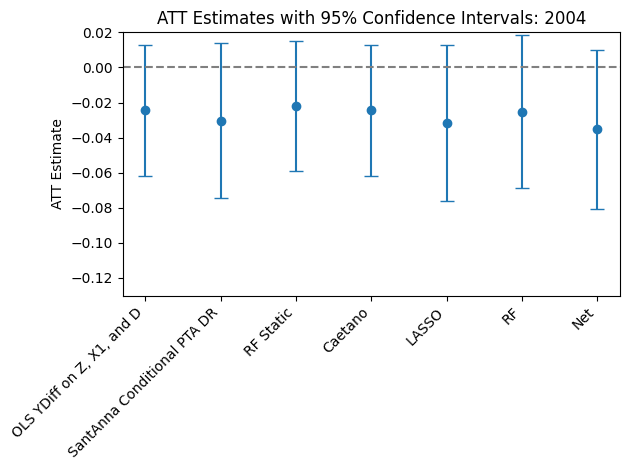

In [8]:
out = plot_att_estimates_with_ci(out_2004, att_2014, std_2014, 'RF Static', "2004",att_SantAnna, std_SantAnna )

In [13]:
out

## 2005

In [4]:
out_2005 = dynamic_riesz_results(2003,2005)
att_2015, std_2015 = -0.049,0.020
att_SantAnna, std_SantAnna= -0.0247,     0.0217  

Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']


Exception ignored in: <finalize object at 0x148a758a1040; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/weakref.py", line 591, in __call__
    return info.func(*info.args, **(info.kwargs or {}))
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 868, in _cleanup
    cls._rmtree(name, ignore_errors=ignore_errors)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 864, in _rmtree
    _shutil.rmtree(name, onerror=onerror)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 731, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 729, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/n/home11/jinhopark/tmp9wt_yih3'


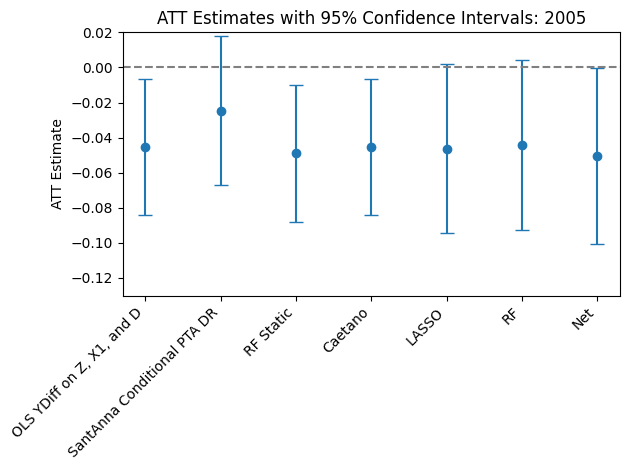

In [5]:
plot_att_estimates_with_ci(out_2005, att_2015, std_2015, 'RF Static', "2005", att_SantAnna, std_SantAnna )

## 2006

In [6]:
out_2006 = dynamic_riesz_results(2003,2006)
att_2006, std_2006 = -0.051, 0.020

att_SantAnna, std_SantAnna =  -0.0497,     0.0212 

Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']


Exception ignored in: <finalize object at 0x148a758fa740; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/weakref.py", line 591, in __call__
    return info.func(*info.args, **(info.kwargs or {}))
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 868, in _cleanup
    cls._rmtree(name, ignore_errors=ignore_errors)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 864, in _rmtree
    _shutil.rmtree(name, onerror=onerror)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 731, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 729, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/n/home11/jinhopark/tmphuvgjeel'
Exception ignored in: <finalize object at 0x148a758f5500; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/

In [15]:
out_2006 = dynamic_riesz_results(2003,2006)
att_2006, std_2006 = -0.051, 0.020

att_SantAnna, std_SantAnna =  -0.0497,     0.0212 

Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']


Exception ignored in: <finalize object at 0x1488e3cbefc0; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/weakref.py", line 591, in __call__
    return info.func(*info.args, **(info.kwargs or {}))
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 868, in _cleanup
    cls._rmtree(name, ignore_errors=ignore_errors)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 864, in _rmtree
    _shutil.rmtree(name, onerror=onerror)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 731, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 729, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/n/home11/jinhopark/tmp3iyn_lo7'
Exception ignored in: <finalize object at 0x1488e3c8a3e0; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/

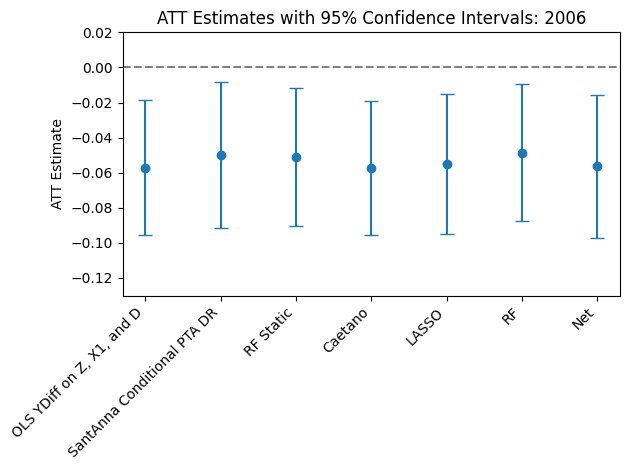

In [7]:
plot_att_estimates_with_ci(out_2006, att_2006, std_2006, 'RF Static', "2006", att_SantAnna, std_SantAnna )

## 2007

In [8]:
out_2007 = dynamic_riesz_results(2003,2007)
att_2007, std_2007 = -0.064, 0.023
att_SantAnna, std_SantAnna= -0.0709    , 0.0232  

Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']


Exception ignored in: <finalize object at 0x148a758fefa0; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/weakref.py", line 591, in __call__
    return info.func(*info.args, **(info.kwargs or {}))
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 868, in _cleanup
    cls._rmtree(name, ignore_errors=ignore_errors)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 864, in _rmtree
    _shutil.rmtree(name, onerror=onerror)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 731, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 729, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/n/home11/jinhopark/tmp_htz0e9h'
Exception ignored in: <finalize object at 0x148a758fed00; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/

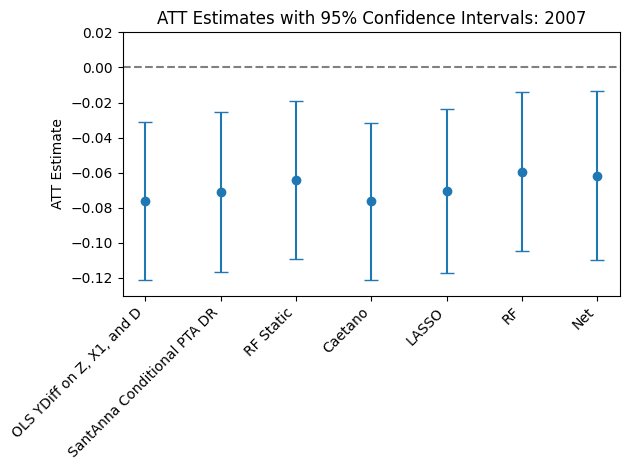

In [9]:
plot_att_estimates_with_ci(out_2007, att_2007, std_2007, 'RF Static', "2007", att_SantAnna, std_SantAnna )

All results computed here.

Overall progress:   0%|          | 0/2 [00:00<?, ?it/s]

Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']











Year 2006: 100%|██████████| 5/5 [12:39<00:00, 151.88s/it, Net]


[2006] computed and cached to: application_results_final/min_wage_cache/results_2006.csv


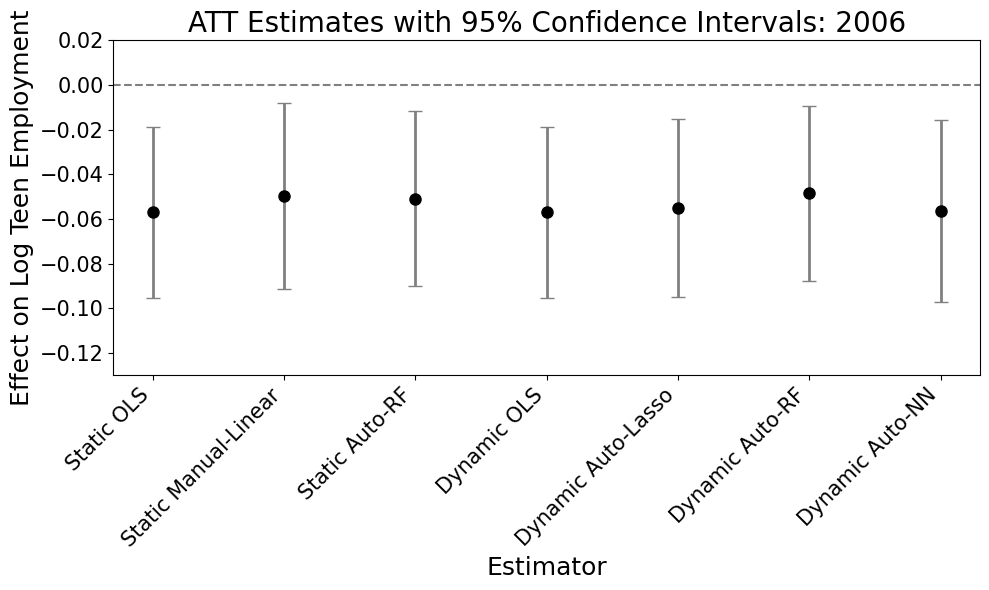

Overall progress:  50%|█████     | 1/2 [12:40<12:40, 760.10s/it]

Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']











Overall progress:  50%|█████     | 1/2 [25:52<25:52, 1552.34s/it]


OSError: Cannot save file into a non-existent directory: 'application_results_final/min_wage_cache'

In [ ]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils.dynamicRieszFunctions import estimateDynamicRiesz
from utils.estimateDiD_OLS import estimateDiD_OLS
from utils.application import *

# ---------------------------------------------------------------
# Hardcoded "Static" results (computed elsewhere; pasted in here)
# ---------------------------------------------------------------
STATIC_RESULTS = {
    2004: {"Static Auto-RF": (-0.022, 0.019), "Static Manual-Linear": (-0.0303, 0.0225)},
    2005: {"Static Auto-RF": (-0.049, 0.020), "Static Manual-Linear": (-0.0247, 0.0217)},
    2006: {"Static Auto-RF": (-0.051, 0.020), "Static Manual-Linear": (-0.0497, 0.0212)},
    2007: {"Static Auto-RF": (-0.064, 0.023), "Static Manual-Linear": (-0.0709, 0.0232)},
}

DYNAMIC_RENAME = {
    "OLS YDiff on Z, X1, and D": "Static OLS",
    "Caetano": "Dynamic OLS",
    "LASSO": "Dynamic Auto-Lasso",
    "RF": "Dynamic Auto-RF",
    "Net": "Dynamic Auto-NN",
}

TITLE_SIZE = 20
AXIS_LABEL_SIZE = 18
TICK_LABEL_SIZE = 15

RESULTS_DIR = "application_results_final/min_wage_cache"
os.makedirs(RESULTS_DIR, exist_ok=True)


def dynamic_riesz_results(start_year, effect_year, treatment_year=2004,
                           baseline_2001=True, folds=5, seed=0, verbose=True):
    data_app = application_data()
    data = data_app.get_data(start_year, effect_year, treatment_year=treatment_year,
                              baseline_2001=baseline_2001)
    X1, X2 = data['X1'], data['X2']
    Y1, Y2 = data['Y1'], data['Y2']
    Z, D = data['Z'], data['D']

    Z_df = pd.DataFrame(Z.numpy())
    X1_df = pd.DataFrame(X1.numpy())

    X_cov = pd.concat([pd.DataFrame(D.numpy(), columns=["D"]), Z_df, X1_df], axis=1)
    Ydiff = np.asarray(Y2) - np.asarray(Y1)
    X_cov = sm.add_constant(X_cov)

    steps = ["OLS", "Caetano", "LASSO", "RF", "Net"]
    pbar = tqdm(steps, desc=f"Year {effect_year}", disable=not verbose)

    rows = []

    pbar.set_postfix_str("OLS")
    ols2 = sm.OLS(Ydiff, X_cov).fit(cov_type="HC1")
    rows.append({
        "method": "OLS YDiff on Z, X1, and D",
        "ATT": float(ols2.params["D"]),
        "SE": float(ols2.bse["D"])
    })
    pbar.update(1)

    pbar.set_postfix_str("Caetano")
    lin_out = estimateDiD_OLS(Y1, Y2, D, Z, X1, X2, seed=seed)
    rows.append({"method": "Caetano", "ATT": lin_out[0], "SE": lin_out[1]})
    pbar.update(1)

    for method in ("LASSO", "RF", "Net"):
        pbar.set_postfix_str(method)
        ATT, STD, *_ = estimateDynamicRiesz(
            Y1, Y2, D, Z, X1, X2, folds,
            method_a=method, method_f=method, seed=seed
        )
        se = STD / np.sqrt(len(Y1))
        rows.append({"method": method, "ATT": ATT.item(), "SE": se.item()})
        pbar.update(1)

    pbar.close()
    return pd.DataFrame(rows)


def get_or_compute_results(year, force_recompute=False, verbose=True):
    cache_path = os.path.join(RESULTS_DIR, f"results_{year}.csv")
    if os.path.exists(cache_path) and not force_recompute:
        if verbose:
            print(f"[{year}] loaded from cache: {cache_path}")
        return pd.read_csv(cache_path)
    out_df = dynamic_riesz_results(2003, year, verbose=verbose)
    out_df.to_csv(cache_path, index=False)
    if verbose:
        print(f"[{year}] computed and cached to: {cache_path}")
    return out_df


def plot_att_estimates(year, force_recompute=False, verbose=True):
    out_df = get_or_compute_results(year, force_recompute=force_recompute, verbose=verbose)
    out_df = out_df.copy()
    out_df["method"] = out_df["method"].replace(DYNAMIC_RENAME)

    static_rows = pd.DataFrame([
        {"method": name, "ATT": vals[0], "SE": vals[1]}
        for name, vals in STATIC_RESULTS[year].items()
    ])

    plot_df = pd.concat([out_df, static_rows], ignore_index=True)

    method_order = [
        "Static OLS", "Static Manual-Linear", "Static Auto-RF",
        "Dynamic OLS", "Dynamic Auto-Lasso", "Dynamic Auto-RF", "Dynamic Auto-NN",
    ]
    plot_df["method"] = pd.Categorical(plot_df["method"], categories=method_order, ordered=True)
    plot_df = plot_df.sort_values("method")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(
        plot_df['method'], plot_df['ATT'],
        yerr=1.96 * plot_df['SE'],
        fmt='o', capsize=5, markersize=8, color='black', ecolor='gray', elinewidth=2
    )
    ax.axhline(0, linestyle='--', color='gray')
    ax.set_xlabel('Estimator', fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel('Effect on Log Teen Employment', fontsize=AXIS_LABEL_SIZE)
    ax.set_title(f'ATT Estimates with 95% Confidence Intervals: {year}', fontsize=TITLE_SIZE)
    ax.set_ylim(-0.13, 0.02)
    ax.tick_params(axis='x', labelsize=TICK_LABEL_SIZE, rotation=45)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
    plt.setp(ax.get_xticklabels(), ha="right")
    plt.tight_layout()
    plt.show()

    return plot_df


# ---------------------------------------------------------------
# Generate all four years, with an overall progress bar too
# ---------------------------------------------------------------
years = (2007)
for year in tqdm(years, desc="Overall progress"):
    plot_att_estimates(year)

Overall progress:   0%|          | 0/1 [00:00<?, ?it/s]

[2007] loaded from cache: results/min_wage_cache/results_2007.csv


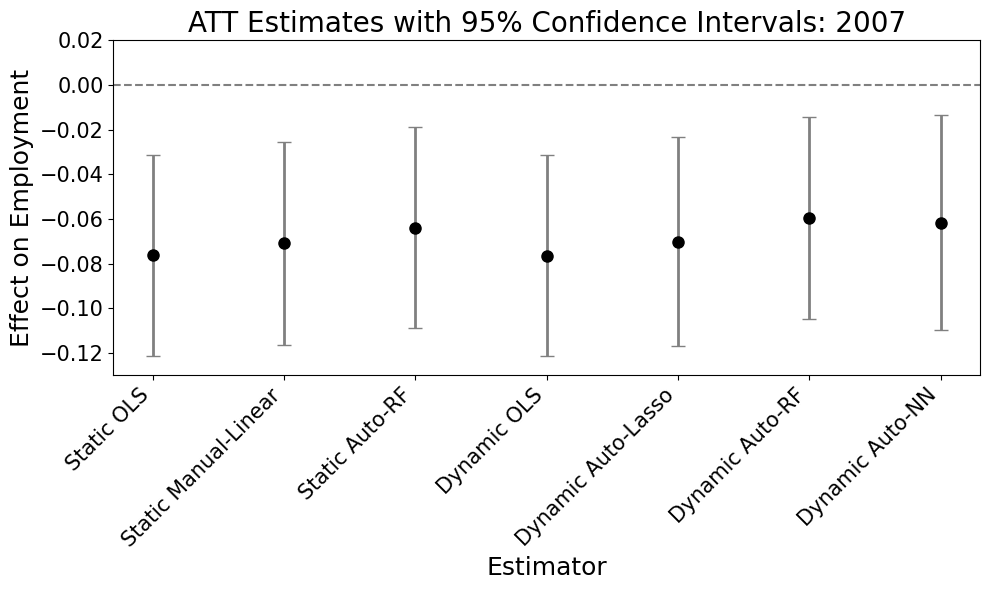

Overall progress: 100%|██████████| 1/1 [00:00<00:00,  2.54it/s]


In [5]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils.dynamicRieszFunctions import estimateDynamicRiesz
from utils.estimateDiD_OLS import estimateDiD_OLS
from utils.application import *

# ---------------------------------------------------------------
# Hardcoded "Static" results (computed elsewhere; pasted in here)
# ---------------------------------------------------------------
STATIC_RESULTS = {
    2004: {"Static Auto-RF": (-0.022, 0.019), "Static Manual-Linear": (-0.0303, 0.0225)},
    2005: {"Static Auto-RF": (-0.049, 0.020), "Static Manual-Linear": (-0.0247, 0.0217)},
    2006: {"Static Auto-RF": (-0.051, 0.020), "Static Manual-Linear": (-0.0497, 0.0212)},
    2007: {"Static Auto-RF": (-0.064, 0.023), "Static Manual-Linear": (-0.0709, 0.0232)},
}

DYNAMIC_RENAME = {
    "OLS YDiff on Z, X1, and D": "Static OLS",
    "Caetano": "Dynamic OLS",
    "LASSO": "Dynamic Auto-Lasso",
    "RF": "Dynamic Auto-RF",
    "Net": "Dynamic Auto-NN",
}

TITLE_SIZE = 20
AXIS_LABEL_SIZE = 18
TICK_LABEL_SIZE = 15

RESULTS_DIR = "results/min_wage_cache"
os.makedirs(RESULTS_DIR, exist_ok=True)


def dynamic_riesz_results(start_year, effect_year, treatment_year=2004,
                           baseline_2001=True, folds=5, seed=0, verbose=True):
    data_app = application_data()
    data = data_app.get_data(start_year, effect_year, treatment_year=treatment_year,
                              baseline_2001=baseline_2001)
    X1, X2 = data['X1'], data['X2']
    Y1, Y2 = data['Y1'], data['Y2']
    Z, D = data['Z'], data['D']

    Z_df = pd.DataFrame(Z.numpy())
    X1_df = pd.DataFrame(X1.numpy())

    X_cov = pd.concat([pd.DataFrame(D.numpy(), columns=["D"]), Z_df, X1_df], axis=1)
    Ydiff = np.asarray(Y2) - np.asarray(Y1)
    X_cov = sm.add_constant(X_cov)

    steps = ["OLS", "Caetano", "LASSO", "RF", "Net"]
    pbar = tqdm(steps, desc=f"Year {effect_year}", disable=not verbose)

    rows = []

    pbar.set_postfix_str("OLS")
    ols2 = sm.OLS(Ydiff, X_cov).fit(cov_type="HC1")
    rows.append({
        "method": "OLS YDiff on Z, X1, and D",
        "ATT": float(ols2.params["D"]),
        "SE": float(ols2.bse["D"])
    })
    pbar.update(1)

    pbar.set_postfix_str("Caetano")
    lin_out = estimateDiD_OLS(Y1, Y2, D, Z, X1, X2, seed=seed)
    rows.append({"method": "Caetano", "ATT": lin_out[0], "SE": lin_out[1]})
    pbar.update(1)

    for method in ("LASSO", "RF", "Net"):
        pbar.set_postfix_str(method)
        ATT, STD, *_ = estimateDynamicRiesz(
            Y1, Y2, D, Z, X1, X2, folds,
            method_a=method, method_f=method, seed=seed
        )
        se = STD / np.sqrt(len(Y1))
        rows.append({"method": method, "ATT": ATT.item(), "SE": se.item()})
        pbar.update(1)

    pbar.close()
    return pd.DataFrame(rows)


def get_or_compute_results(year, force_recompute=False, verbose=True):
    cache_path = os.path.join(RESULTS_DIR, f"results_{year}.csv")
    if os.path.exists(cache_path) and not force_recompute:
        if verbose:
            print(f"[{year}] loaded from cache: {cache_path}")
        return pd.read_csv(cache_path)
    out_df = dynamic_riesz_results(2003, year, verbose=verbose)
    out_df.to_csv(cache_path, index=False)
    if verbose:
        print(f"[{year}] computed and cached to: {cache_path}")
    return out_df


def plot_att_estimates(year, force_recompute=False, verbose=True):
    out_df = get_or_compute_results(year, force_recompute=force_recompute, verbose=verbose)
    out_df = out_df.copy()
    out_df["method"] = out_df["method"].replace(DYNAMIC_RENAME)

    static_rows = pd.DataFrame([
        {"method": name, "ATT": vals[0], "SE": vals[1]}
        for name, vals in STATIC_RESULTS[year].items()
    ])

    plot_df = pd.concat([out_df, static_rows], ignore_index=True)

    method_order = [
        "Static OLS", "Static Manual-Linear", "Static Auto-RF",
        "Dynamic OLS", "Dynamic Auto-Lasso", "Dynamic Auto-RF", "Dynamic Auto-NN",
    ]
    plot_df["method"] = pd.Categorical(plot_df["method"], categories=method_order, ordered=True)
    plot_df = plot_df.sort_values("method")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(
        plot_df['method'], plot_df['ATT'],
        yerr=1.96 * plot_df['SE'],
        fmt='o', capsize=5, markersize=8, color='black', ecolor='gray', elinewidth=2
    )
    ax.axhline(0, linestyle='--', color='gray')
    ax.set_xlabel('Estimator', fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel('Effect on Employment', fontsize=AXIS_LABEL_SIZE)
    ax.set_title(f'ATT Estimates with 95% Confidence Intervals: {year}', fontsize=TITLE_SIZE)
    ax.set_ylim(-0.13, 0.02)
    ax.tick_params(axis='x', labelsize=TICK_LABEL_SIZE, rotation=45)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
    plt.setp(ax.get_xticklabels(), ha="right")
    plt.tight_layout()
    plt.show()

    return plot_df


# ---------------------------------------------------------------
# Run for 2007 only, save to results/min_wage_cache
# ---------------------------------------------------------------
years = (2007,)
for year in tqdm(years, desc="Overall progress"):
    plot_att_estimates(year)

[2005] loaded from cache: results/min_wage_cache/results_2005.csv


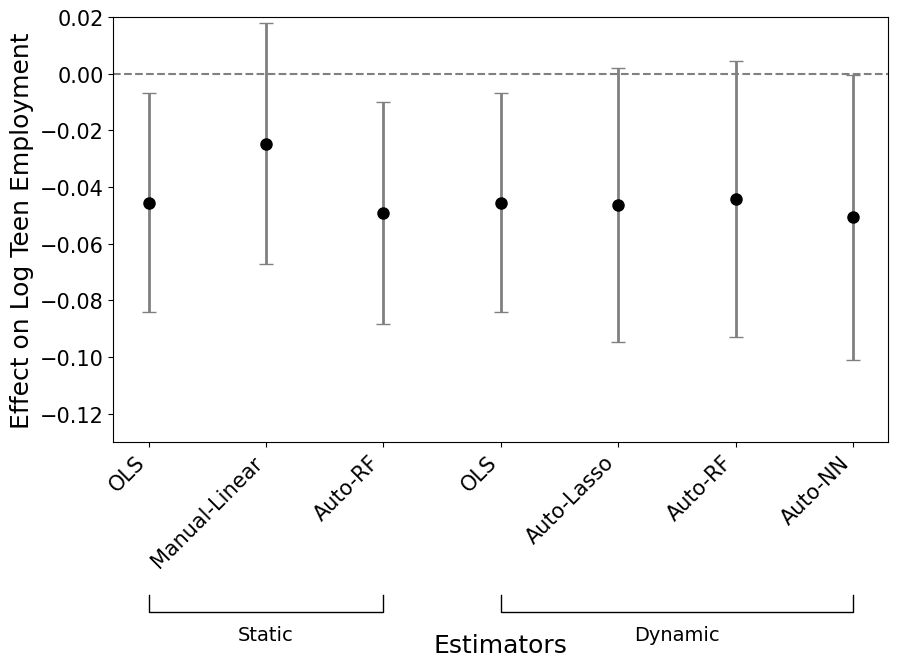

          method       ATT        SE    group
0            OLS -0.045459  0.019760   Static
1  Manual-Linear -0.024700  0.021700   Static
2        Auto-RF -0.049000  0.020000   Static
3            OLS -0.045500  0.019700  Dynamic
4     Auto-Lasso -0.046239  0.024665  Dynamic
5        Auto-RF -0.044265  0.024794  Dynamic
6        Auto-NN -0.050661  0.025632  Dynamic


In [ ]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils.dynamicRieszFunctions import estimateDynamicRiesz
from utils.estimateDiD_OLS import estimateDiD_OLS
from utils.application import *

# ---------------------------------------------------------------
# Hardcoded "Static" results (computed elsewhere; pasted in here)
# Source: https://arxiv.org/pdf/2307.04527
# ---------------------------------------------------------------
STATIC_RESULTS = {
    2004: {"Auto-RF": (-0.022, 0.019), "Manual-Linear": (-0.0303, 0.0225)},
    2005: {"Auto-RF": (-0.049, 0.020), "Manual-Linear": (-0.0247, 0.0217)},
    2006: {"Auto-RF": (-0.051, 0.020), "Manual-Linear": (-0.0497, 0.0212)},
    2007: {"Auto-RF": (-0.064, 0.023), "Manual-Linear": (-0.0709, 0.0232)},
}

# These two groups reuse the SAME label strings ("OLS", "Auto-RF") on purpose —
# the bracket below the x-axis is what disambiguates Static vs Dynamic.
STATIC_ORDER = ["OLS", "Manual-Linear", "Auto-RF"]
DYNAMIC_ORDER = ["OLS", "Auto-Lasso", "Auto-RF", "Auto-NN"]

AXIS_LABEL_SIZE = 18
TICK_LABEL_SIZE = 15
BRACKET_LABEL_SIZE = 14

RESULTS_DIR = "results/min_wage_cache"
os.makedirs(RESULTS_DIR, exist_ok=True)


def dynamic_riesz_results(start_year, effect_year, treatment_year=2004,
                           baseline_2001=True, folds=5, seed=0, verbose=True):
    data_app = application_data()
    data = data_app.get_data(start_year, effect_year, treatment_year=treatment_year,
                              baseline_2001=baseline_2001)
    X1, X2 = data['X1'], data['X2']
    Y1, Y2 = data['Y1'], data['Y2']
    Z, D = data['Z'], data['D']

    Z_df = pd.DataFrame(Z.numpy())
    X1_df = pd.DataFrame(X1.numpy())

    X_cov = pd.concat([pd.DataFrame(D.numpy(), columns=["D"]), Z_df, X1_df], axis=1)
    Ydiff = np.asarray(Y2) - np.asarray(Y1)
    X_cov = sm.add_constant(X_cov)

    steps = ["OLS", "Caetano", "LASSO", "RF", "Net"]
    pbar = tqdm(steps, desc=f"Year {effect_year}", disable=not verbose)

    rows = []

    pbar.set_postfix_str("OLS")
    ols2 = sm.OLS(Ydiff, X_cov).fit(cov_type="HC1")
    rows.append({
        "method": "OLS YDiff on Z, X1, and D",
        "ATT": float(ols2.params["D"]),
        "SE": float(ols2.bse["D"])
    })
    pbar.update(1)

    pbar.set_postfix_str("Caetano")
    lin_out = estimateDiD_OLS(Y1, Y2, D, Z, X1, X2, seed=seed)
    rows.append({"method": "Caetano", "ATT": lin_out[0], "SE": lin_out[1]})
    pbar.update(1)

    for method in ("LASSO", "RF", "Net"):
        pbar.set_postfix_str(method)
        ATT, STD, *_ = estimateDynamicRiesz(
            Y1, Y2, D, Z, X1, X2, folds,
            method_a=method, method_f=method, seed=seed
        )
        se = STD / np.sqrt(len(Y1))
        rows.append({"method": method, "ATT": ATT.item(), "SE": se.item()})
        pbar.update(1)

    pbar.close()
    return pd.DataFrame(rows)


def get_or_compute_results(year, force_recompute=False, verbose=True):
    cache_path = os.path.join(RESULTS_DIR, f"results_{year}.csv")
    if os.path.exists(cache_path) and not force_recompute:
        if verbose:
            print(f"[{year}] loaded from cache: {cache_path}")
        return pd.read_csv(cache_path)
    out_df = dynamic_riesz_results(2003, year, verbose=verbose)
    out_df.to_csv(cache_path, index=False)
    if verbose:
        print(f"[{year}] computed and cached to: {cache_path}")
    return out_df


def add_group_bracket(ax, x0, x1, label, y=-0.34, h=0.04, text_offset=0.03):
    trans = ax.get_xaxis_transform()
    ax.plot(
        [x0, x0, x1, x1],
        [y + h, y, y, y + h],
        transform=trans,
        clip_on=False,
        linewidth=1.0,
        color="black",
    )
    ax.text(
        (x0 + x1) / 2,
        y - text_offset,
        label,
        transform=trans,
        ha="center",
        va="top",
        fontsize=BRACKET_LABEL_SIZE,
        clip_on=False,
    )


def build_plot_df(year, force_recompute=False, verbose=True):
    """Builds the plotting dataframe: Static rows first (STATIC_ORDER),
    then Dynamic rows (DYNAMIC_ORDER). Both groups reuse label strings
    like "OLS" and "Auto-RF" — only the bracket distinguishes them."""
    out_df = get_or_compute_results(year, force_recompute=force_recompute, verbose=verbose)
    out_df = out_df.copy()
    out_df["ATT"] = pd.to_numeric(out_df["ATT"], errors="coerce")
    out_df["SE"] = pd.to_numeric(out_df["SE"], errors="coerce")

    # --- Static block: plain OLS + hardcoded Manual-Linear / Auto-RF ---
    static_block = out_df[out_df["method"] == "OLS YDiff on Z, X1, and D"].copy()
    static_block["method"] = "OLS"
    static_block = pd.concat([
        static_block,
        pd.DataFrame([
            {"method": name, "ATT": float(vals[0]), "SE": float(vals[1])}
            for name, vals in STATIC_RESULTS[year].items()
        ])
    ], ignore_index=True)
    static_block = static_block.set_index("method").reindex(STATIC_ORDER).reset_index()
    static_block["group"] = "Static"

    # --- Dynamic block: Caetano (renamed OLS), LASSO, RF, Net ---
    dynamic_rename = {
        "Caetano": "OLS",
        "LASSO": "Auto-Lasso",
        "RF": "Auto-RF",
        "Net": "Auto-NN",
    }
    dynamic_block = out_df[out_df["method"].isin(dynamic_rename.keys())].copy()
    dynamic_block["method"] = dynamic_block["method"].replace(dynamic_rename)
    dynamic_block = dynamic_block.set_index("method").reindex(DYNAMIC_ORDER).reset_index()
    dynamic_block["group"] = "Dynamic"

    plot_df = pd.concat([static_block, dynamic_block], ignore_index=True)
    return plot_df


def plot_att_estimates(year, force_recompute=False, verbose=True):
    plot_df = build_plot_df(year, force_recompute=force_recompute, verbose=verbose)

    if not pd.api.types.is_numeric_dtype(plot_df["ATT"]) or not pd.api.types.is_numeric_dtype(plot_df["SE"]):
        print("dtype problem detected:")
        print(plot_df.dtypes)
        print(plot_df[["method", "ATT", "SE"]])
        raise TypeError("ATT or SE column is not numeric — see printed dataframe above.")

    x = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(10, 8.5))
    ax.errorbar(
        x, plot_df['ATT'].to_numpy(),
        yerr=1.96 * plot_df['SE'].to_numpy(),
        fmt='o', capsize=5, markersize=8, color='black', ecolor='gray', elinewidth=2
    )
    ax.axhline(0, linestyle='--', color='gray')

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['method'], rotation=45, ha="right", fontsize=TICK_LABEL_SIZE)
    ax.set_xlabel('Estimators', fontsize=AXIS_LABEL_SIZE, labelpad=45)
    ax.set_ylabel('Effect on Log Teen Employment', fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
    ax.set_ylim(-0.13, 0.02)

    n_static = len(STATIC_ORDER)
    n_total = len(plot_df)
    add_group_bracket(ax, 0, n_static - 1, "Static", y=-0.40)
    add_group_bracket(ax, n_static, n_total - 1, "Dynamic", y=-0.40)

    fig.subplots_adjust(bottom=0.38)
    plt.show()

    return plot_df
    plot_df = build_plot_df(year, force_recompute=force_recompute, verbose=verbose)

    if not pd.api.types.is_numeric_dtype(plot_df["ATT"]) or not pd.api.types.is_numeric_dtype(plot_df["SE"]):
        print("dtype problem detected:")
        print(plot_df.dtypes)
        print(plot_df[["method", "ATT", "SE"]])
        raise TypeError("ATT or SE column is not numeric — see printed dataframe above.")

    x = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(10, 9))
    ax.errorbar(
        x, plot_df['ATT'].to_numpy(),
        yerr=1.96 * plot_df['SE'].to_numpy(),
        fmt='o', capsize=5, markersize=8, color='black', ecolor='gray', elinewidth=2
    )
    ax.axhline(0, linestyle='--', color='gray')

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['method'], rotation=45, ha="right", fontsize=TICK_LABEL_SIZE)
    ax.set_xlabel('Estimators', fontsize=AXIS_LABEL_SIZE, labelpad=60)
    ax.set_ylabel('Effect on Log Teen Employment', fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
    ax.set_ylim(-0.13, 0.02)

    n_static = len(STATIC_ORDER)
    n_total = len(plot_df)
    add_group_bracket(ax, 0, n_static - 1, "Static", y=-0.45)
    add_group_bracket(ax, n_static, n_total - 1, "Dynamic", y=-0.45)

    fig.subplots_adjust(bottom=0.42)
    plt.show()

    return plot_df

    plot_df = build_plot_df(year, force_recompute=force_recompute, verbose=verbose)

    if not pd.api.types.is_numeric_dtype(plot_df["ATT"]) or not pd.api.types.is_numeric_dtype(plot_df["SE"]):
        print("dtype problem detected:")
        print(plot_df.dtypes)
        print(plot_df[["method", "ATT", "SE"]])
        raise TypeError("ATT or SE column is not numeric — see printed dataframe above.")

    x = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.errorbar(
        x, plot_df['ATT'].to_numpy(),
        yerr=1.96 * plot_df['SE'].to_numpy(),
        fmt='o', capsize=5, markersize=8, color='black', ecolor='gray', elinewidth=2
    )
    ax.axhline(0, linestyle='--', color='gray')

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['method'], rotation=45, ha="right", fontsize=TICK_LABEL_SIZE)
    ax.set_xlabel('Estimators', fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel('Effect on Log Teen Employment', fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
    ax.set_ylim(-0.13, 0.02)

    n_static = len(STATIC_ORDER)
    n_total = len(plot_df)
    add_group_bracket(ax, 0, n_static - 1, "Static", y=-0.30)
    add_group_bracket(ax, n_static, n_total - 1, "Dynamic", y=-0.30)

    fig.subplots_adjust(bottom=0.32)
    plt.show()

    return plot_df


# ---------------------------------------------------------------
# Run for 2007 only, using cache (no recompute)
# ---------------------------------------------------------------
plot_df_2007 = plot_att_estimates(2005)
print(plot_df_2007)

[2007] loaded from cache: results/min_wage_cache/results_2007.csv


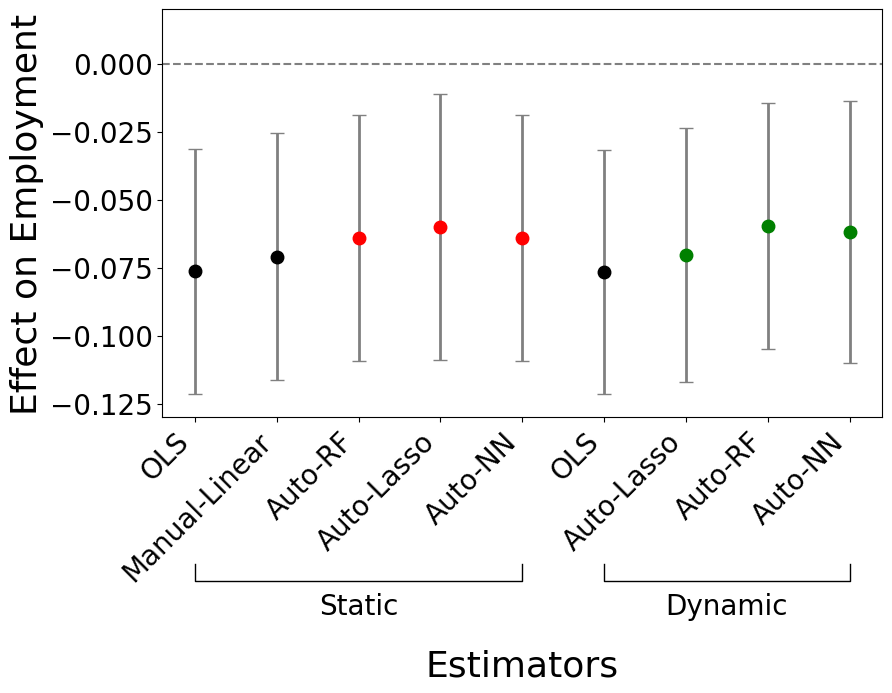

          method       ATT        SE    group
0            OLS -0.076354  0.022961   Static
1  Manual-Linear -0.070900  0.023200   Static
2        Auto-RF -0.064000  0.023000   Static
3     Auto-Lasso -0.060000  0.025000   Static
4        Auto-NN -0.064000  0.023000   Static
5            OLS -0.076400  0.022900  Dynamic
6     Auto-Lasso -0.070302  0.023905  Dynamic
7        Auto-RF -0.059525  0.023086  Dynamic
8        Auto-NN -0.061735  0.024600  Dynamic


In [10]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils.dynamicRieszFunctions import estimateDynamicRiesz
from utils.estimateDiD_OLS import estimateDiD_OLS
from utils.application import *

# ---------------------------------------------------------------
# Hardcoded "Static" results (computed elsewhere; pasted in here)
# Source: Chernozhukov, Newey, Singh, Syrgkanis (2023/2024),
# "Automatic Debiased Machine Learning for Covariate Shifts" (arxiv.org/abs/2307.04527)
#   Auto-RF     <- (RF, RF-RR)             [Tables 1-2]
#   Auto-Lasso  <- (Lasso-3d, Lasso-RR-3d) [Tables 1-2]
#   Auto-NN     <- (RF, NN-RR)             [Tables 1-2]
# ---------------------------------------------------------------
STATIC_RESULTS = {
    2004: {"Auto-RF": (-0.022, 0.019), "Manual-Linear": (-0.0303, 0.0225),
           "Auto-Lasso": (-0.024, 0.020), "Auto-NN": (-0.022, 0.019)},
    2005: {"Auto-RF": (-0.049, 0.020), "Manual-Linear": (-0.0247, 0.0217),
           "Auto-Lasso": (-0.045, 0.021), "Auto-NN": (-0.046, 0.020)},
    2006: {"Auto-RF": (-0.051, 0.020), "Manual-Linear": (-0.0497, 0.0212),
           "Auto-Lasso": (-0.052, 0.021), "Auto-NN": (-0.052, 0.020)},
    2007: {"Auto-RF": (-0.064, 0.023), "Manual-Linear": (-0.0709, 0.0232),
           "Auto-Lasso": (-0.060, 0.025), "Auto-NN": (-0.064, 0.023)},
}

# These two groups reuse the SAME label strings ("OLS", "Auto-RF") on purpose —
# the bracket below the x-axis and the point color are what disambiguate
# Static vs Dynamic.
STATIC_ORDER = ["OLS", "Manual-Linear", "Auto-RF", "Auto-Lasso", "Auto-NN"]
DYNAMIC_ORDER = ["OLS", "Auto-Lasso", "Auto-RF", "Auto-NN"]

# --- Colors: manual/parametric (OLS, Manual-Linear) black,
#     Static Auto-* methods red, Dynamic Auto-* methods green ---
COLOR_OLS = "black"
COLOR_STATIC = "red"
COLOR_DYNAMIC = "green"

# --- Font sizes bumped up for legibility inside a 2x2 figure grid ---
TITLE_SIZE = 24
AXIS_LABEL_SIZE = 26
TICK_LABEL_SIZE = 20
BRACKET_LABEL_SIZE = 20

RESULTS_DIR = "results/min_wage_cache"
os.makedirs(RESULTS_DIR, exist_ok=True)


def dynamic_riesz_results(start_year, effect_year, treatment_year=2004,
                           baseline_2001=True, folds=5, seed=0, verbose=True):
    data_app = application_data()
    data = data_app.get_data(start_year, effect_year, treatment_year=treatment_year,
                              baseline_2001=baseline_2001)
    X1, X2 = data['X1'], data['X2']
    Y1, Y2 = data['Y1'], data['Y2']
    Z, D = data['Z'], data['D']

    Z_df = pd.DataFrame(Z.numpy())
    X1_df = pd.DataFrame(X1.numpy())

    X_cov = pd.concat([pd.DataFrame(D.numpy(), columns=["D"]), Z_df, X1_df], axis=1)
    Ydiff = np.asarray(Y2) - np.asarray(Y1)
    X_cov = sm.add_constant(X_cov)

    steps = ["OLS", "Caetano", "LASSO", "RF", "Net"]
    pbar = tqdm(steps, desc=f"Year {effect_year}", disable=not verbose)

    rows = []

    pbar.set_postfix_str("OLS")
    ols2 = sm.OLS(Ydiff, X_cov).fit(cov_type="HC1")
    rows.append({
        "method": "OLS YDiff on Z, X1, and D",
        "ATT": float(ols2.params["D"]),
        "SE": float(ols2.bse["D"])
    })
    pbar.update(1)

    pbar.set_postfix_str("Caetano")
    lin_out = estimateDiD_OLS(Y1, Y2, D, Z, X1, X2, seed=seed)
    rows.append({"method": "Caetano", "ATT": lin_out[0], "SE": lin_out[1]})
    pbar.update(1)

    for method in ("LASSO", "RF", "Net"):
        pbar.set_postfix_str(method)
        ATT, STD, *_ = estimateDynamicRiesz(
            Y1, Y2, D, Z, X1, X2, folds,
            method_a=method, method_f=method, seed=seed
        )
        se = STD / np.sqrt(len(Y1))
        rows.append({"method": method, "ATT": ATT.item(), "SE": se.item()})
        pbar.update(1)

    pbar.close()
    return pd.DataFrame(rows)


def get_or_compute_results(year, force_recompute=False, verbose=True):
    cache_path = os.path.join(RESULTS_DIR, f"results_{year}.csv")
    if os.path.exists(cache_path) and not force_recompute:
        if verbose:
            print(f"[{year}] loaded from cache: {cache_path}")
        return pd.read_csv(cache_path)
    out_df = dynamic_riesz_results(2003, year, verbose=verbose)
    out_df.to_csv(cache_path, index=False)
    if verbose:
        print(f"[{year}] computed and cached to: {cache_path}")
    return out_df


def add_group_bracket(ax, x0, x1, label, y=-0.34, h=0.04, text_offset=0.03):
    trans = ax.get_xaxis_transform()
    ax.plot(
        [x0, x0, x1, x1],
        [y + h, y, y, y + h],
        transform=trans,
        clip_on=False,
        linewidth=1.0,
        color="black",
    )
    ax.text(
        (x0 + x1) / 2,
        y - text_offset,
        label,
        transform=trans,
        ha="center",
        va="top",
        fontsize=BRACKET_LABEL_SIZE,
        clip_on=False,
    )


def build_plot_df(year, force_recompute=False, verbose=True):
    """Builds the plotting dataframe: Static rows first (STATIC_ORDER),
    then Dynamic rows (DYNAMIC_ORDER). Both groups reuse label strings
    like "OLS" and "Auto-RF" — the bracket and point color distinguish them."""
    out_df = get_or_compute_results(year, force_recompute=force_recompute, verbose=verbose)
    out_df = out_df.copy()
    out_df["ATT"] = pd.to_numeric(out_df["ATT"], errors="coerce")
    out_df["SE"] = pd.to_numeric(out_df["SE"], errors="coerce")

    # --- Static block: plain OLS + hardcoded Manual-Linear / Auto-RF / Auto-Lasso / Auto-NN ---
    static_block = out_df[out_df["method"] == "OLS YDiff on Z, X1, and D"].copy()
    static_block["method"] = "OLS"
    static_block = pd.concat([
        static_block,
        pd.DataFrame([
            {"method": name, "ATT": float(vals[0]), "SE": float(vals[1])}
            for name, vals in STATIC_RESULTS[year].items()
        ])
    ], ignore_index=True)
    static_block = static_block.set_index("method").reindex(STATIC_ORDER).reset_index()
    static_block["group"] = "Static"

    # --- Dynamic block: Caetano (renamed OLS), LASSO, RF, Net ---
    dynamic_rename = {
        "Caetano": "OLS",
        "LASSO": "Auto-Lasso",
        "RF": "Auto-RF",
        "Net": "Auto-NN",
    }
    dynamic_block = out_df[out_df["method"].isin(dynamic_rename.keys())].copy()
    dynamic_block["method"] = dynamic_block["method"].replace(dynamic_rename)
    dynamic_block = dynamic_block.set_index("method").reindex(DYNAMIC_ORDER).reset_index()
    dynamic_block["group"] = "Dynamic"

    plot_df = pd.concat([static_block, dynamic_block], ignore_index=True)
    return plot_df


def _point_colors(plot_df):
    """Manual/parametric methods (OLS, Manual-Linear) are always black;
    non-manual Static Auto-* methods are red; non-manual Dynamic Auto-* methods are green."""
    manual_methods = {"OLS", "Manual-Linear"}
    colors = []
    for _, row in plot_df.iterrows():
        if row["method"] in manual_methods:
            colors.append(COLOR_OLS)
        elif row["group"] == "Static":
            colors.append(COLOR_STATIC)
        else:
            colors.append(COLOR_DYNAMIC)
    return colors


def plot_att_estimates(year, force_recompute=False, verbose=True):
    plot_df = build_plot_df(year, force_recompute=force_recompute, verbose=verbose)

    if not pd.api.types.is_numeric_dtype(plot_df["ATT"]) or not pd.api.types.is_numeric_dtype(plot_df["SE"]):
        print("dtype problem detected:")
        print(plot_df.dtypes)
        print(plot_df[["method", "ATT", "SE"]])
        raise TypeError("ATT or SE column is not numeric — see printed dataframe above.")

    x = np.arange(len(plot_df))
    colors = _point_colors(plot_df)

    fig, ax = plt.subplots(figsize=(10, 8.5))

    # Plot each point individually so each can take its own color.
    # (errorbar's ecolor stays gray throughout, only marker color varies by group.)
    for xi, att, se, c in zip(x, plot_df['ATT'].to_numpy(), plot_df['SE'].to_numpy(), colors):
        ax.errorbar(
            xi, att, yerr=1.96 * se,
            fmt='o', capsize=5, markersize=9,
            color=c, ecolor='gray', elinewidth=2
        )

    ax.axhline(0, linestyle='--', color='gray')

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['method'], rotation=45, ha="right", fontsize=TICK_LABEL_SIZE)
    ax.set_xlabel('Estimators', fontsize=AXIS_LABEL_SIZE, labelpad=45)
    ax.set_ylabel('Effect on Employment', fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
    ax.set_ylim(-0.13, 0.02)

    n_static = len(STATIC_ORDER)
    n_total = len(plot_df)
    add_group_bracket(ax, 0, n_static - 1, "Static", y=-0.40)
    add_group_bracket(ax, n_static, n_total - 1, "Dynamic", y=-0.40)

    fig.subplots_adjust(bottom=0.40, left=0.18)
    plt.show()

    return plot_df


# ---------------------------------------------------------------
# Run for 2005 only, using cache (no recompute)
# ---------------------------------------------------------------
plot_df_2005 = plot_att_estimates(2007)
print(plot_df_2005)